# Optimizadores para Deep Learning con JAX, Flax y Optax

**MDS211 — Machine Learning · Universidad Católica del Maule**

Entrenar una red neuronal es **minimizar** una función de pérdida no convexa
y de muy alta dimensión respecto de sus parámetros (pesos y sesgos):

$$\min_{\theta}\; f(\theta), \qquad f(\theta)=\frac{1}{n}\sum_{i=1}^{n}\ell\big(\hat{y}_i(\theta),\,y_i\big).$$

El algoritmo que elige *cómo* dar cada paso —el **optimizador**— es decisivo
para la velocidad y la calidad del entrenamiento. En este laboratorio
recorremos la familia de métodos de primer orden de la clase de optimización:

- **Descenso de gradiente** y su versión **estocástica / minibatch** (SGD).
- **Momentum** y **Nesterov**: acumular inercia para atravesar valles estrechos.
- Métodos de **tasa adaptativa**: **AdaGrad**, **RMSProp** y **Adam**.
- **Programación de la tasa de aprendizaje** (*learning rate schedules*).

Usaremos el ecosistema **JAX** (autograd + JIT), **Flax** (`flax.nnx`, para
definir la red) y **Optax** (biblioteca de optimizadores).


## 1. Importar librerías necesarias

`jax` provee diferenciación automática (`jax.grad`) y compilación (`jax.jit`);
`optax` implementa los optimizadores como *transformaciones de gradiente*
componibles; `flax.nnx` es la API moderna de Flax para construir redes.
Fijamos una única semilla `RANDOM_STATE = 42` para toda la práctica.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import optax
from flax import nnx

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42          # semilla única para todo el laboratorio
np.random.seed(RANDOM_STATE)

print("JAX  ", jax.__version__)
print("Optax", optax.__version__)
print("Dispositivo:", jax.devices()[0])

JAX   0.10.1
Optax 0.2.8
Dispositivo: cuda:0


## 2. La optimización en deep learning

En general $f$ es **no convexa** y de altísima dimensión: no buscamos el óptimo
global exacto, sino una solución suficientemente buena obtenida rápido. Para
**ver** cómo se comporta cada optimizador, empezamos con un caso de juguete en
2D que podemos dibujar: un **valle estrecho**.

### 2.1 Un valle estrecho: superficie de prueba 2D

Usamos una cuadrática **mal condicionada**

$$f(w_0, w_1) = \tfrac{1}{2}\left(w_0^2 + 20\,w_1^2\right),$$

cuyo mínimo está en el origen. La dirección $w_1$ es 20 veces más "empinada"
que $w_0$: sus curvas de nivel son elipses muy alargadas. Es el escenario que
hace **zig-zaguear** al descenso de gradiente puro (sensible al escalamiento de
las variables), y donde momentum y los métodos adaptativos marcan la diferencia.

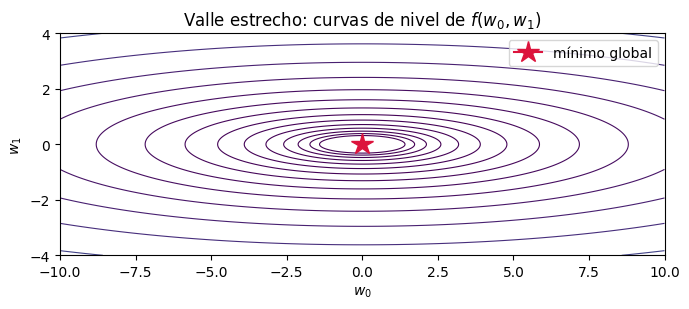

In [2]:
def f_valle(w):
    # Cuadrática mal condicionada: mínimo global en (0, 0)
    return 0.5 * (w[0] ** 2 + 20.0 * w[1] ** 2)

# Malla para dibujar las curvas de nivel
w0 = np.linspace(-10, 10, 400)
w1 = np.linspace(-4, 4, 400)
W0, W1 = np.meshgrid(w0, w1)
Z = 0.5 * (W0 ** 2 + 20.0 * W1 ** 2)

plt.figure(figsize=(7, 3.2))
plt.contour(W0, W1, Z, levels=np.logspace(0, 3, 18), cmap="viridis", linewidths=0.8)
plt.plot(0, 0, marker="*", color="crimson", markersize=16, label="mínimo global")
plt.title("Valle estrecho: curvas de nivel de $f(w_0,w_1)$")
plt.xlabel("$w_0$"); plt.ylabel("$w_1$"); plt.legend(); plt.tight_layout()
plt.show()

## 3. Comparación de optimizadores sobre el valle

Un optimizador de Optax es una **transformación de gradiente**: un par de
funciones `init` / `update`. El bucle manual es siempre el mismo —se ve
explícitamente la actualización $\theta \leftarrow \theta + \text{update}$—
y solo cambiamos la transformación:

```python
state = opt.init(params)
g = jax.grad(f)(params)
updates, state = opt.update(g, state, params)
params = optax.apply_updates(params, updates)
```

Aplicamos este bucle, partiendo del **mismo punto inicial**, con:

| Optimizador | Idea añadida (ver clase) |
|---|---|
| `sgd`              | Paso en la dirección de máximo descenso |
| `sgd(momentum)`    | Inercia / velocidad acumulada |
| `sgd(nesterov)`    | Gradiente en la posición proyectada |
| `adagrad`          | Tasa por parámetro (suma de $g^2$) |
| `rmsprop`          | Media móvil de $g^2$ |
| `adam`             | Momentum + RMSProp + corrección de sesgo |


In [3]:
def run_optimizer(opt, x0, fun, n_steps=50):
    # Ejecuta el bucle de Optax y devuelve (trayectoria, pérdidas)
    grad_fun = jax.grad(fun)
    x = jnp.asarray(x0, dtype=jnp.float32)
    state = opt.init(x)
    traj, losses = [np.asarray(x)], [float(fun(x))]
    for _ in range(n_steps):
        g = grad_fun(x)
        updates, state = opt.update(g, state, x)
        x = optax.apply_updates(x, updates)
        traj.append(np.asarray(x))
        losses.append(float(fun(x)))
    return np.array(traj), np.array(losses)

# Cada método con una tasa razonable para este problema concreto.
optimizadores = {
    "SGD":      optax.sgd(0.045),
    "Momentum": optax.sgd(0.04, momentum=0.9),
    "Nesterov": optax.sgd(0.04, momentum=0.9, nesterov=True),
    "AdaGrad":  optax.adagrad(2.5),
    "RMSProp":  optax.rmsprop(0.6),
    "Adam":     optax.adam(1.2),
}

x_inicial = np.array([9.0, 2.0], dtype=np.float32)
resultados = {nombre: run_optimizer(opt, x_inicial, f_valle)
              for nombre, opt in optimizadores.items()}
for nombre, (traj, losses) in resultados.items():
    print(f"{nombre:<9s} pérdida final = {losses[-1]:.4g}")

SGD       pérdida final = 0.4053
Momentum  pérdida final = 0.2793
Nesterov  pérdida final = 0.02581
AdaGrad   pérdida final = 6.62e-08
RMSProp   pérdida final = 0.03692
Adam      pérdida final = 0.1289


Dibujamos las **trayectorias** sobre las curvas de nivel: así se ve el
zig-zag del SGD puro frente a la trayectoria suavizada del momentum y al avance
"reescalado" de los métodos adaptativos.

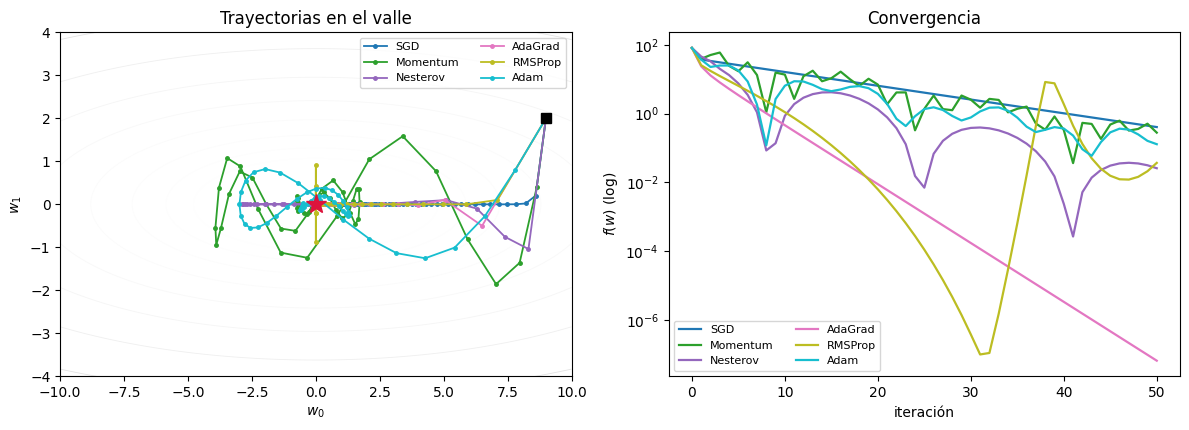

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

# --- (a) trayectorias sobre las curvas de nivel ---
ax[0].contour(W0, W1, Z, levels=np.logspace(0, 3, 18), cmap="Greys", linewidths=0.6)
colores = plt.cm.tab10(np.linspace(0, 1, len(resultados)))
for (nombre, (traj, _)), c in zip(resultados.items(), colores):
    ax[0].plot(traj[:, 0], traj[:, 1], "-o", color=c, ms=2.5, lw=1.3, label=nombre)
ax[0].plot(0, 0, marker="*", color="crimson", ms=15)
ax[0].plot(*x_inicial, marker="s", color="black", ms=7)
ax[0].set_title("Trayectorias en el valle"); ax[0].set_xlabel("$w_0$"); ax[0].set_ylabel("$w_1$")
ax[0].legend(fontsize=8, ncol=2)

# --- (b) pérdida vs iteración (escala log) ---
for (nombre, (_, losses)), c in zip(resultados.items(), colores):
    ax[1].plot(losses, color=c, lw=1.6, label=nombre)
ax[1].set_yscale("log")
ax[1].set_title("Convergencia"); ax[1].set_xlabel("iteración"); ax[1].set_ylabel("$f(w)$ (log)")
ax[1].legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

**Lectura.** El SGD puro avanza rápido en la dirección plana pero rebota
de pared a pared en la dirección empinada (zig-zag): es **sensible al
escalamiento**. Momentum y Nesterov **cancelan** las oscilaciones y refuerzan
la dirección consistente hacia el mínimo. AdaGrad y RMSProp **adaptan una tasa
por coordenada**, neutralizando la anisotropía del valle. Estas son justamente
las ventajas que buscamos al entrenar redes reales.

## 4. Entrenar una red neuronal con Flax y Optax

Pasamos del juguete 2D a un problema de aprendizaje real: clasificar el conjunto
**two moons**. Aquí $f$ es la pérdida de una red sobre los datos, y no podemos
calcular el gradiente completo barato sobre millones de ejemplos: usamos
**minibatches** (el caballo de batalla del entrenamiento moderno).

### 4.1 Generar datos sintéticos

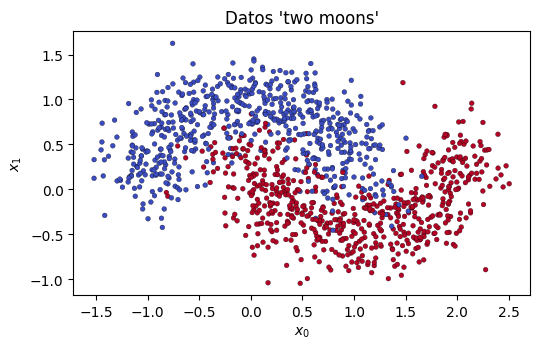

In [5]:
X, y = make_moons(n_samples=1200, noise=0.25, random_state=RANDOM_STATE)

plt.figure(figsize=(5.5, 3.6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=12, edgecolors="k", linewidths=0.2)
plt.title("Datos 'two moons'"); plt.xlabel("$x_0$"); plt.ylabel("$x_1$")
plt.tight_layout(); plt.show()

### 4.2 Dividir en entrenamiento/prueba y estandarizar

Como en los laboratorios previos: `train_test_split` con `stratify=y`, y
estandarización con la media/desviación del **conjunto de entrenamiento** (las
estadísticas de test no deben filtrarse). JAX trabaja en `float32`.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)

x_mean, x_std = X_train.mean(axis=0), X_train.std(axis=0)
X_train = ((X_train - x_mean) / x_std).astype(np.float32)
X_test  = ((X_test  - x_mean) / x_std).astype(np.float32)
y_train = y_train.astype(np.int32)
y_test  = y_test.astype(np.int32)

print("Entrenamiento:", X_train.shape, "| Prueba:", X_test.shape)

Entrenamiento: (840, 2) | Prueba: (360, 2)


### 4.3 Definir el MLP con `flax.nnx`

`flax.nnx` define la red como una clase: las capas se crean en `__init__`
(reciben un generador de números aleatorios `rngs` para inicializar sus pesos)
y el paso hacia adelante se escribe en `__call__`. Construimos un MLP de dos
capas ocultas con activación ReLU y **un único logit** de salida: la
probabilidad de la clase 1 se obtiene aplicándole la sigmoide.

In [7]:
class MLP(nnx.Module):
    def __init__(self, din=2, dh=32, dout=1, *, rngs):
        self.l1 = nnx.Linear(din, dh, rngs=rngs)
        self.l2 = nnx.Linear(dh,  dh, rngs=rngs)
        self.l3 = nnx.Linear(dh, dout, rngs=rngs)

    def __call__(self, x):
        x = nnx.relu(self.l1(x))
        x = nnx.relu(self.l2(x))
        return self.l3(x)[:, 0]    # un solo logit por ejemplo (sin sigmoide)

# Inspección rápida de la arquitectura
demo = MLP(rngs=nnx.Rngs(RANDOM_STATE))
print("Salida (logits) para un lote de 4 ejemplos:", demo(jnp.ones((4, 2))).shape)

Salida (logits) para un lote de 4 ejemplos: (4,)


In [8]:
print("Salida (logits) para un lote de 32 ejemplos:", demo(jnp.ones((32, 2))).shape)

Salida (logits) para un lote de 32 ejemplos: (32,)


### 4.4 Bucle de entrenamiento por minibatches

El `train_step` calcula la pérdida (entropía cruzada binaria con sigmoide,
`optax.sigmoid_binary_cross_entropy`, que opera sobre el logit), obtiene los
gradientes con `nnx.value_and_grad` y aplica la actualización del optimizador.
Lo decoramos con `@nnx.jit` para compilarlo. `train_model` arma una red **nueva
con la misma semilla** y recorre los datos por minibatches barajados, de modo
que al comparar optimizadores **solo cambie el optimizador** (misma
inicialización y mismos lotes).

In [9]:
def train_model(make_tx, epochs=60, batch_size=32, seed=RANDOM_STATE, verbose=False):
    # Entrena un MLP con el optimizador que devuelve make_tx().
    # Devuelve (modelo, historial_de_perdida_por_epoca).
    model = MLP(rngs=nnx.Rngs(seed))
    optimizer = nnx.Optimizer(model, make_tx(), wrt=nnx.Param)

    @nnx.jit
    def train_step(model, optimizer, xb, yb):
        def loss_fn(m):
            logits = m(xb)                       # (B,) un logit por ejemplo
            return optax.sigmoid_binary_cross_entropy(
                logits, yb.astype(jnp.float32)).mean()
        loss, grads = nnx.value_and_grad(loss_fn)(model)
        optimizer.update(model, grads)
        return loss

    rng = np.random.default_rng(seed)
    n = len(X_train)
    historial = []
    for epoch in range(epochs):
        idx = rng.permutation(n)
        perdidas = []
        for s in range(0, n, batch_size):
            b = idx[s:s + batch_size]
            loss = train_step(model, optimizer,
                              jnp.asarray(X_train[b]), jnp.asarray(y_train[b]))
            perdidas.append(float(loss))
        historial.append(np.mean(perdidas))
        if verbose and (epoch + 1) % 15 == 0:
            print(f"  época {epoch+1:3d} | pérdida {historial[-1]:.4f}")
    return model, np.array(historial)


def accuracy(model, X, y):
    logits = model(jnp.asarray(X))               # (N,)
    pred = (logits > 0).astype(jnp.int32)        # logit > 0  <=>  sigmoide > 0.5
    return float((pred == jnp.asarray(y)).mean())


# Prueba rápida con Adam
modelo_adam, hist_adam = train_model(lambda: optax.adam(3e-3), verbose=True)
print(f"Exactitud en prueba (Adam): {accuracy(modelo_adam, X_test, y_test):.3f}")

  época  15 | pérdida 0.1764
  época  30 | pérdida 0.1727
  época  45 | pérdida 0.1661
  época  60 | pérdida 0.1578
Exactitud en prueba (Adam): 0.950


### 4.5 Comparar optimizadores en el entrenamiento real

Entrenamos la **misma** arquitectura con distintos optimizadores y comparamos
sus curvas de pérdida y su exactitud final. Las tasas de aprendizaje están
elegidas en rangos típicos de cada método (SGD necesita una tasa mayor; Adam y
RMSProp, mucho menor).

In [10]:
configs = {
    "SGD":           lambda: optax.sgd(0.3),
    "Momentum":      lambda: optax.sgd(0.1, momentum=0.9),
    "Nesterov":      lambda: optax.sgd(0.1, momentum=0.9, nesterov=True),
    "AdaGrad":       lambda: optax.adagrad(0.1),
    "RMSProp":       lambda: optax.rmsprop(3e-3),
    "Adam":          lambda: optax.adam(3e-3),
}

historiales, exactitudes = {}, {}
for nombre, make_tx in configs.items():
    modelo, hist = train_model(make_tx)
    historiales[nombre] = hist
    exactitudes[nombre] = accuracy(modelo, X_test, y_test)
    print(f"{nombre:<9s} | pérdida final {hist[-1]:.4f} | exactitud test {exactitudes[nombre]:.3f}")

SGD       | pérdida final 0.1736 | exactitud test 0.953
Momentum  | pérdida final 0.1568 | exactitud test 0.939
Nesterov  | pérdida final 0.1624 | exactitud test 0.947
AdaGrad   | pérdida final 0.1638 | exactitud test 0.947
RMSProp   | pérdida final 0.1673 | exactitud test 0.950
Adam      | pérdida final 0.1578 | exactitud test 0.950


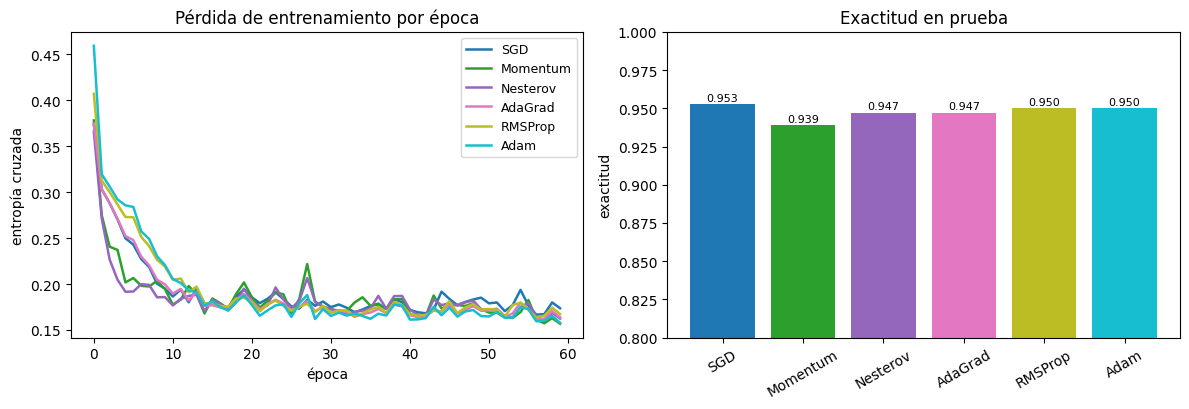

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

colores = plt.cm.tab10(np.linspace(0, 1, len(historiales)))
for (nombre, hist), c in zip(historiales.items(), colores):
    ax[0].plot(hist, color=c, lw=1.8, label=nombre)
ax[0].set_title("Pérdida de entrenamiento por época")
ax[0].set_xlabel("época"); ax[0].set_ylabel("entropía cruzada"); ax[0].legend(fontsize=9)

nombres = list(exactitudes.keys())
ax[1].bar(nombres, [exactitudes[n] for n in nombres], color=colores)
ax[1].set_ylim(0.8, 1.0); ax[1].set_title("Exactitud en prueba")
ax[1].set_ylabel("exactitud"); ax[1].tick_params(axis="x", rotation=30)
for i, n in enumerate(nombres):
    ax[1].text(i, exactitudes[n] + 0.002, f"{exactitudes[n]:.3f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

**Lectura.** Adam y RMSProp suelen **bajar la pérdida más rápido** sin
casi ajuste; SGD con momentum/Nesterov alcanza una pérdida comparable pero exige
una tasa bien elegida. En la práctica, *Adam* es un punto de partida robusto y
*SGD con momentum* suele **generalizar muy bien** cuando se ajusta con cuidado.
No existe un optimizador único "mejor".

## 5. Programación de la tasa de aprendizaje (*schedules*)

Mantener $\alpha$ fija rara vez es óptimo: conviene **empezar alto** (avanzar
rápido) y **bajar** (asentarse en el mínimo). Optax expone estos esquemas como
*schedules* —funciones de la iteración— que se pasan directamente como
`learning_rate` a cualquier optimizador. Comparamos tres esquemas clásicos.

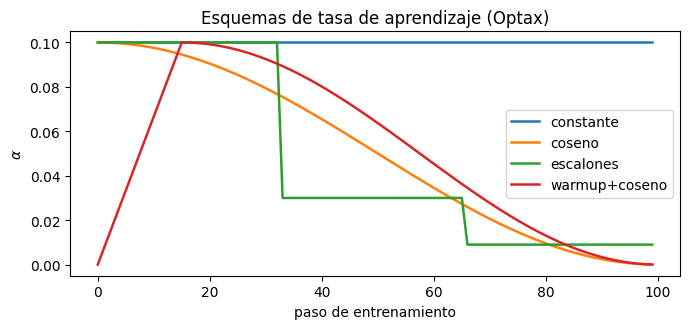

In [12]:
total_steps = 100
schedules = {
    "constante":      optax.constant_schedule(0.1),
    "coseno":         optax.cosine_decay_schedule(0.1, total_steps),
    "escalones":      optax.piecewise_constant_schedule(
                          0.1, {33: 0.3, 66: 0.3}),   # x0.3 en los pasos 33 y 66
    "warmup+coseno":  optax.warmup_cosine_decay_schedule(
                          init_value=0.0, peak_value=0.1,
                          warmup_steps=15, decay_steps=total_steps),
}

pasos = np.arange(total_steps)
plt.figure(figsize=(7, 3.4))
for nombre, sched in schedules.items():
    plt.plot(pasos, [float(sched(t)) for t in pasos], lw=1.8, label=nombre)
plt.title("Esquemas de tasa de aprendizaje (Optax)")
plt.xlabel("paso de entrenamiento"); plt.ylabel(r"$\alpha$"); plt.legend()
plt.tight_layout(); plt.show()

Entrenamos Adam con una tasa **constante** frente a un esquema
**warmup + coseno** (con la misma tasa pico) para ver el efecto del *schedule*
sobre la curva de pérdida. El número de pasos por época es
`ceil(n_train / batch_size)`.

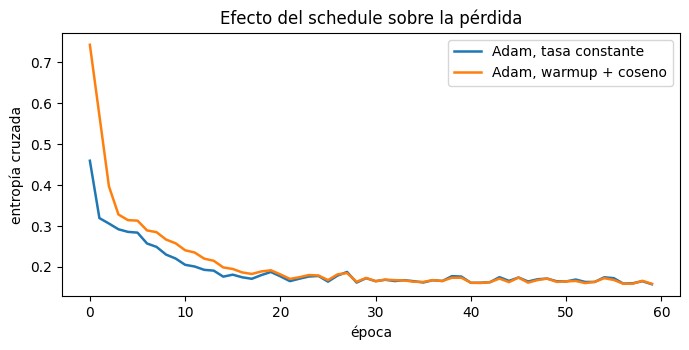

In [13]:
import math
pasos_por_epoca = math.ceil(len(X_train) / 32)
epocas = 60
pasos_totales = pasos_por_epoca * epocas

sched = optax.warmup_cosine_decay_schedule(
    init_value=0.0, peak_value=3e-3,
    warmup_steps=5 * pasos_por_epoca, decay_steps=pasos_totales)

_, hist_constante = train_model(lambda: optax.adam(3e-3), epochs=epocas)
_, hist_schedule  = train_model(lambda: optax.adam(sched), epochs=epocas)

plt.figure(figsize=(7, 3.6))
plt.plot(hist_constante, lw=1.8, label="Adam, tasa constante")
plt.plot(hist_schedule,  lw=1.8, label="Adam, warmup + coseno")
plt.title("Efecto del schedule sobre la pérdida")
plt.xlabel("época"); plt.ylabel("entropía cruzada"); plt.legend()
plt.tight_layout(); plt.show()

## 6. Evaluación: frontera de decisión

Finalmente visualizamos la **frontera de decisión** aprendida por el mejor
modelo (Adam), evaluando la red sobre una malla densa del plano.

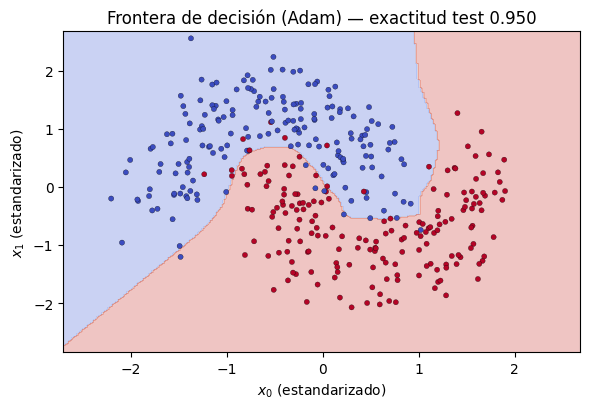

In [14]:
# malla en el espacio estandarizado
h = 0.02
x0_min, x0_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
x1_min, x1_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
gx, gy = np.meshgrid(np.arange(x0_min, x0_max, h), np.arange(x1_min, x1_max, h))
malla = np.c_[gx.ravel(), gy.ravel()].astype(np.float32)

logits = modelo_adam(jnp.asarray(malla))
zz = np.asarray((logits > 0).astype(jnp.int32)).reshape(gx.shape)

plt.figure(figsize=(6, 4.2))
plt.contourf(gx, gy, zz, alpha=0.3, cmap="coolwarm")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="coolwarm",
            s=14, edgecolors="k", linewidths=0.2)
plt.title(f"Frontera de decisión (Adam) — exactitud test {accuracy(modelo_adam, X_test, y_test):.3f}")
plt.xlabel("$x_0$ (estandarizado)"); plt.ylabel("$x_1$ (estandarizado)")
plt.tight_layout(); plt.show()

## 7. Resumen

- El **descenso de gradiente** sigue la dirección de máximo descenso; su **tasa
  de aprendizaje** es el hiperparámetro crítico.
- **SGD / minibatch** hacen viable el entrenamiento a gran escala a costa de
  gradientes ruidosos; el ruido incluso ayuda a escapar de mínimos pobres.
- El **momentum** (y **Nesterov**) acumula progreso en direcciones favorables y
  suaviza el zig-zag en valles estrechos.
- Los métodos de **tasa adaptativa** (**AdaGrad**, **RMSProp**, **Adam**) ajustan
  el paso por parámetro; Adam combina momentum + RMSProp + corrección de sesgo.
- La **programación de la tasa** (coseno, escalones, *warmup*) reduce la
  dependencia del ajuste manual.

Con **Optax** todos estos métodos son una sola línea (`optax.adam(...)`,
`optax.sgd(..., momentum=...)`), y con **Flax** (`flax.nnx`) el bucle de
entrenamiento es idéntico sin importar el optimizador elegido.

> No existe un optimizador único "mejor": la elección depende del problema, los
> datos y el presupuesto de cómputo.

### Ejercicios propuestos

1. Cambia el `batch_size` (p. ej. 8, 64, 256) y observa el efecto sobre el ruido
   de la curva de pérdida y la exactitud final.
2. Añade **regularización** (decaimiento de pesos) combinando
   `optax.adamw(...)` o `optax.chain(optax.add_decayed_weights(1e-4), optax.adam(...))`.
3. Reemplaza two moons por `make_circles` o por un problema de **regresión** y
   adapta la pérdida (`optax.l2_loss`).
4. Implementa **decaimiento por hipergradiente** ajustando $\alpha$ con la regla
   $\alpha^{(k)} = \alpha^{(k-1)} + \mu\,g^{(k)\top}g^{(k-1)}$ de la clase.

### Para profundizar

- Zhang, Lipton, Li & Smola, *Dive into Deep Learning*, cap. 12 — https://d2l.ai/chapter_optimization/index.html
- Documentación de [Optax](https://optax.readthedocs.io) y [Flax NNX](https://flax.readthedocs.io).
- Kingma & Ba (2015), *Adam: A Method for Stochastic Optimization*, ICLR.
